# HSE RecSys HW4 — EDA

Exploratory Data Analysis для датасета онлайн-магазина: история взаимодействий пользователей с товарами + каталог.

**План:**
1. Загрузка данных и базовые размеры
2. Анализ взаимодействий (train): пропуски, типы, временной диапазон
3. Пользователи и товары: распределения активности, long tail
4. Таргеты: `is_purchased`, `rating`, CTR по impressions
5. Временной анализ
6. Каталог товаров: category_tags, series_id, author_ids
7. Overlap train/test users и item cold-start
8. Выводы для построения модели

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.max_columns', 50)

DATA_DIR = Path('dataset')
TRAIN_PATH = DATA_DIR / 'train.pq'
ITEMS_PATH = DATA_DIR / 'items.pq'
TEST_USERS_PATH = DATA_DIR / 'test_users.csv'
SAMPLE_SUB_PATH = DATA_DIR / 'sample_submission.csv'

## 1. Загрузка данных

In [2]:
train = pd.read_parquet(TRAIN_PATH)
items = pd.read_parquet(ITEMS_PATH)
test_users = pd.read_csv(TEST_USERS_PATH) if TEST_USERS_PATH.exists() else None
sample_sub = pd.read_csv(SAMPLE_SUB_PATH) if SAMPLE_SUB_PATH.exists() else None

print('train     :', train.shape)
print('items     :', items.shape)
if test_users is not None: print('test_users:', test_users.shape)
if sample_sub is not None: print('sample_sub:', sample_sub.shape)

train     : (11373426, 6)
items     : (34323, 4)
test_users: (185282, 1)
sample_sub: (3705640, 2)


In [3]:
print('=== train dtypes ==='); print(train.dtypes)
print('\n=== items dtypes ==='); print(items.dtypes)
train.head(3)

=== train dtypes ===
user_id                  int64
item_id                  int64
is_purchased              bool
rating                   int64
timestamp       datetime64[us]
impressions             object
dtype: object

=== items dtypes ===
item_id           int64
category_tags    object
series_id        object
author_ids       object
dtype: object


,user_id,item_id,is_purchased,rating,timestamp,impressions
0,324824,18327,True,4,2014-05-15 12:27:08,"[18904, 24061, 27026, 28728, 28878, 27370, 183..."
1,116285,22214,False,0,2014-05-15 12:27:20,"[7626, 15860, 13908, 9968, 9702, 18901, 19103,..."
2,64299,31070,True,5,2014-05-15 12:27:20,"[20402, 32052, 29601, 11623, 22715, 4500, 5520..."


In [4]:
items.head(3)

,item_id,category_tags,series_id,author_ids
0,5114,"[166918, 175145, 50357, 186689, 63050, 34286, ...","[2480, 13423, 13449, 783]",[9277]
1,28709,"[166918, 153826, 47635, 183297, 153869, 18044,...",[11007],[5779]
2,14357,"[166918, 186689, 183297, 56766, 56660, 50357, ...",[13388],"[5906, 11935]"


## 2. Train: пропуски, типы, диапазоны

In [5]:
print('Пропуски в train:')
print(train.isna().sum())
print('\nMemory usage (MB):', train.memory_usage(deep=True).sum() / 1e6)

Пропуски в train:
user_id         0
item_id         0
is_purchased    0
rating          0
timestamp       0
impressions     0
dtype: int64

Memory usage (MB): 1740.13431


In [6]:
print('Период взаимодействий:', train['timestamp'].min(), '→', train['timestamp'].max())
print('Длительность:', train['timestamp'].max() - train['timestamp'].min())

Период взаимодействий: 2014-05-15 12:27:08 → 2016-12-10 02:40:09
Длительность: 939 days 14:13:01


## 3. Пользователи и товары — распределения активности

In [7]:
n_users = train['user_id'].nunique()
n_items = train['item_id'].nunique()
n_inter = len(train)
density = n_inter / (n_users * n_items)
print(f'Уникальных пользователей: {n_users:,}')
print(f'Уникальных товаров     : {n_items:,}')
print(f'Взаимодействий         : {n_inter:,}')
print(f'Sparsity               : {1 - density:.6f}')
print(f'Avg interactions/user  : {n_inter / n_users:.2f}')
print(f'Avg interactions/item  : {n_inter / n_items:.2f}')

Уникальных пользователей: 348,111
Уникальных товаров     : 31,221
Взаимодействий         : 11,373,426
Sparsity               : 0.998954
Avg interactions/user  : 32.67
Avg interactions/item  : 364.29


In [8]:
user_counts = train.groupby('user_id').size()
item_counts = train.groupby('item_id').size()

print('=== Interactions per user ===')
print(user_counts.describe(percentiles=[.5, .9, .95, .99]))
print('\n=== Interactions per item ===')
print(item_counts.describe(percentiles=[.5, .9, .95, .99]))

=== Interactions per user ===
count    348111.000000
mean         32.671837
std          81.222512
min           1.000000
50%          10.000000
90%          80.000000
95%         134.000000
99%         320.000000
max        7123.000000
dtype: float64

=== Interactions per item ===
count    31221.000000
mean       364.287691
std       2071.053939
min          1.000000
50%         31.000000
90%        535.000000
95%       1227.000000
99%       6123.800000
max      87097.000000
dtype: float64


Top 1.49% items cover 50% of interactions
Top 8.47% items cover 80% of interactions
Top 17.65% items cover 90% of interactions


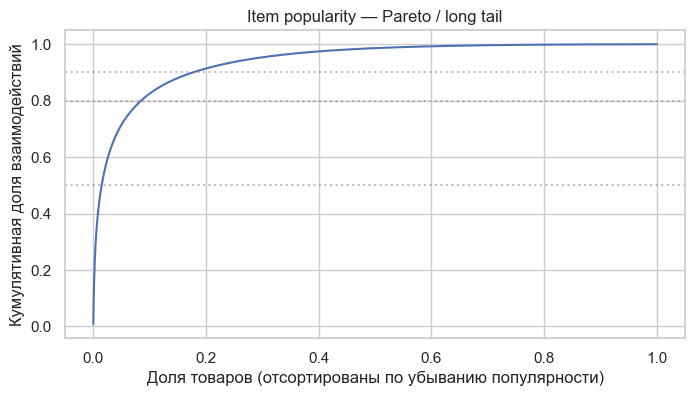

In [9]:
# Долевой график популярности товаров (какая доля топ-N покрывает X% interactions)
sorted_items = item_counts.sort_values(ascending=False).values
cum = np.cumsum(sorted_items) / sorted_items.sum()
frac_items = np.arange(1, len(cum) + 1) / len(cum)
plt.figure(figsize=(8, 4))
plt.plot(frac_items, cum)
plt.xlabel('Доля товаров (отсортированы по убыванию популярности)')
plt.ylabel('Кумулятивная доля взаимодействий')
plt.title('Item popularity — Pareto / long tail')
for q in (0.5, 0.8, 0.9):
    idx = np.searchsorted(cum, q)
    plt.axhline(q, color='grey', ls=':', alpha=.5)
    print(f'Top {frac_items[idx]*100:.2f}% items cover {q*100:.0f}% of interactions')
plt.show()

## 4. Таргеты: is_purchased, rating, CTR

In [10]:
purchase_rate = train['is_purchased'].mean()
print(f'Доля покупок среди взаимодействий: {purchase_rate:.4f}')
print(train['is_purchased'].value_counts())

Доля покупок среди взаимодействий: 0.3918
is_purchased
False    6917100
True     4456326
Name: count, dtype: int64


=== rating distribution (включая 0 = не оценил) ===
rating
0    7268361
1      83820
2     244239
3     861453
4    1441848
5    1473705
Name: count, dtype: int64

Доля оценённых: 0.3609
Mean rating (когда оценил): 3.969


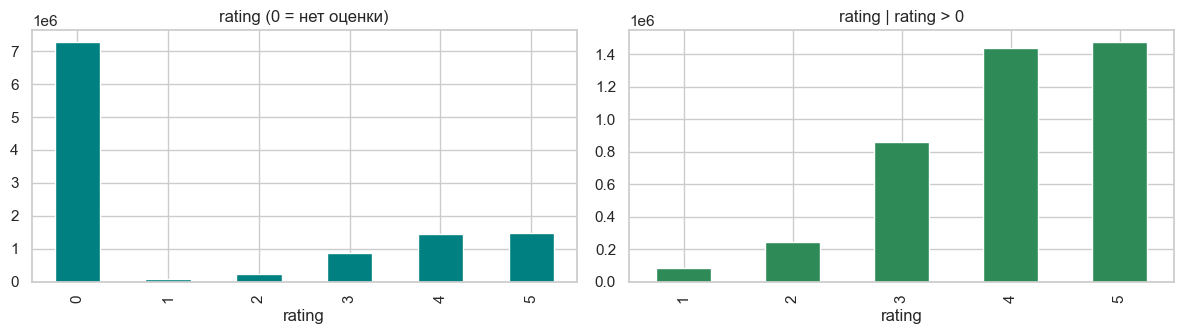

In [11]:
print('=== rating distribution (включая 0 = не оценил) ===')
print(train['rating'].value_counts().sort_index())
rated = train[train['rating'] > 0]
print(f'\nДоля оценённых: {len(rated)/len(train):.4f}')
print(f'Mean rating (когда оценил): {rated["rating"].mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
train['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('rating (0 = нет оценки)')
rated['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('rating | rating > 0')
plt.tight_layout(); plt.show()

In [12]:
# Связь rating и is_purchased
pd.crosstab(train['rating'], train['is_purchased'], normalize='columns').round(3)

is_purchased,False,True
rating,,
0,1.0,0.079
1,0.0,0.019
2,0.0,0.055
3,0.0,0.193
4,0.0,0.324
5,0.0,0.331


In [13]:
# CTR proxy: item_id присутствует ли в impressions (sanity-check) на сэмпле
sample = train.sample(min(50000, len(train)), random_state=42)
in_slate = sample.apply(lambda r: r['item_id'] in r['impressions'], axis=1)
print(f'Доля строк, где item_id есть в своём слейте: {in_slate.mean():.4f}')

# Глобальная популярность товаров в impressions vs клик-популярность
from itertools import chain
imp_pop = Counter(chain.from_iterable(sample['impressions'].tolist()))
click_pop = Counter(sample['item_id'].tolist())
common = list(set(imp_pop) & set(click_pop))[:10000]
imp_arr = np.array([imp_pop[i] for i in common])
clk_arr = np.array([click_pop[i] for i in common])
ctr = clk_arr / np.maximum(imp_arr, 1)
print(f'Средний item CTR (на сэмпле): {ctr.mean():.4f}, median: {np.median(ctr):.4f}')

Доля строк, где item_id есть в своём слейте: 1.0000
Средний item CTR (на сэмпле): 0.1174, median: 0.0630


## 5. Временной анализ

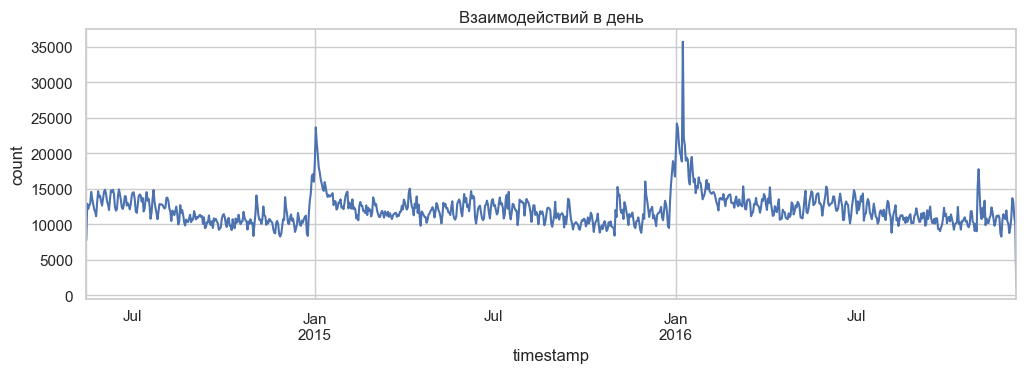

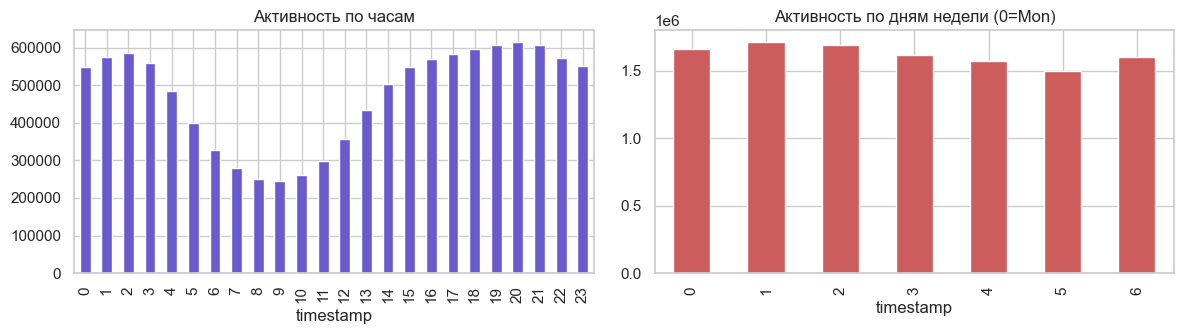

In [14]:
daily = train.set_index('timestamp').resample('D').size()
plt.figure(figsize=(12, 3.5))
daily.plot()
plt.title('Взаимодействий в день')
plt.ylabel('count'); plt.show()

# По часам / дням недели
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
train['timestamp'].dt.hour.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='slateblue')
axes[0].set_title('Активность по часам')
train['timestamp'].dt.dayofweek.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Активность по дням недели (0=Mon)')
plt.tight_layout(); plt.show()

In [15]:
# Time-based split рекомендация: возьмём последние N% для валидации
q90 = train['timestamp'].quantile(0.9)
print(f'90% квантиль времени: {q90}')
print(f'Доля train (до q90): {(train["timestamp"] <= q90).mean():.3f}')
print(f'Доля val   (после) : {(train["timestamp"] >  q90).mean():.3f}')

90% квантиль времени: 2016-08-27 02:07:58.500000
Доля train (до q90): 0.900
Доля val   (после) : 0.100


## 6. Каталог товаров

In [16]:
print('items columns:', items.columns.tolist())
print('Пропуски:'); print(items.isna().sum())
print('Дубли item_id:', items['item_id'].duplicated().sum())

items columns: ['item_id', 'category_tags', 'series_id', 'author_ids']
Пропуски:
item_id          0
category_tags    0
series_id        0
author_ids       0
dtype: int64
Дубли item_id: 0


In [17]:
# Длины списков category_tags / series_id / author_ids
for col in ['category_tags', 'series_id', 'author_ids']:
    if col in items.columns:
        lens = items[col].apply(lambda x: len(x) if x is not None else 0)
        print(f'{col:>15}: mean={lens.mean():.2f}, median={lens.median():.0f}, max={lens.max()}, empty={(lens==0).mean():.3f}')

  category_tags: mean=80.58, median=100, max=438, empty=0.000
      series_id: mean=0.60, median=1, max=4, empty=0.429
     author_ids: mean=1.31, median=1, max=52, empty=0.000


In [18]:
# Топ категорий / авторов
from itertools import chain
for col in ['category_tags', 'series_id', 'author_ids']:
    if col not in items.columns:
        continue
    vals = list(chain.from_iterable(items[col].dropna().tolist()))
    cnt = Counter(vals)
    print(f'\n=== {col}: unique={len(cnt):,}, total_assignments={len(vals):,} ===')
    print('Top-10:', cnt.most_common(10))


=== category_tags: unique=189,697, total_assignments=2,765,683 ===
Top-10: [(np.int64(166918), 34126), (np.int64(186689), 33106), (np.int64(50357), 29492), (np.int64(183297), 27597), (np.int64(65824), 24103), (np.int64(64555), 22234), (np.int64(34286), 21407), (np.int64(124287), 20584), (np.int64(142381), 19078), (np.int64(93278), 17118)]

=== series_id: unique=15,302, total_assignments=20,748 ===
Top-10: [(np.int64(5524), 13), (np.int64(1264), 10), (np.int64(1756), 10), (np.int64(3388), 9), (np.int64(1637), 9), (np.int64(3319), 8), (np.int64(2176), 8), (np.int64(14721), 8), (np.int64(3276), 7), (np.int64(4013), 7)]

=== author_ids: unique=16,445, total_assignments=45,056 ===
Top-10: [(np.int64(4595), 426), (np.int64(1272), 209), (np.int64(3528), 166), (np.int64(9277), 124), (np.int64(477), 121), (np.int64(10824), 115), (np.int64(6914), 88), (np.int64(4484), 85), (np.int64(16034), 84), (np.int64(4068), 82)]


## 7. Train ↔ Test users overlap, item cold-start

In [19]:
if test_users is not None:
    train_users = set(train['user_id'].unique())
    test_user_set = set(test_users['user_id'].unique())
    print(f'Test users         : {len(test_user_set):,}')
    print(f'∩ с train          : {len(test_user_set & train_users):,}')
    print(f'cold-start users   : {len(test_user_set - train_users):,}')
    print(f'cold-start ratio   : {len(test_user_set - train_users)/len(test_user_set):.4f}')
else:
    print('test_users.csv отсутствует на диске')

Test users         : 185,282
∩ с train          : 185,282
cold-start users   : 0
cold-start ratio   : 0.0000


In [20]:
# Items в каталоге, но не встречаются в train → cold items
train_items = set(train['item_id'].unique())
cat_items = set(items['item_id'].unique())
print(f'Items в каталоге : {len(cat_items):,}')
print(f'Items в train    : {len(train_items):,}')
print(f'В каталоге, но нет в train (cold): {len(cat_items - train_items):,}')
print(f'В train, но нет в каталоге      : {len(train_items - cat_items):,}')

Items в каталоге : 34,323
Items в train    : 31,221
В каталоге, но нет в train (cold): 3,102
В train, но нет в каталоге      : 0


## 8. Выводы для моделирования

- **Sparsity** очень высокая → подходят матричные разложения / two-tower / sequence-модели.
- **Long tail** по items → нужны popularity-baseline + content-фичи (`category_tags`, `series_id`, `author_ids`) для холодных товаров.
- **`is_purchased`** сильно несбалансирован → положительные сэмплы редки, для CE нужен negative sampling.
- **`rating`** разрежен (много нулей = не оценил) → не использовать как прямой target, лучше как дополнительную фичу/вес.
- **`impressions`** даёт богатый сигнал для negative sampling (показанные, но не выбранные товары) и для расчёта CTR-фич.
- **Временной сплит** обязателен: последние ~10% по времени → валидация, чтобы не было лика будущего.
- **Cold-start users** в test → для них fallback на popularity / content-based.
- **Финальный submit**: топ-20 на пользователя из `test_users.csv`, формат как в `sample_submission.csv`.

---
## 9. Моделирование

Дальше реализуем план из [`plans/HW4_recsys_plan.md`](../plans/HW4_recsys_plan.md): time-split → datamart →
baselines → ALS → EASE → DSSM (cold-friendly two-tower) → LightGBM LambdaRank.

Главная метрика — `NDCG@20`. Весь код модулирован в [`src/`](src/) и переиспользуется.

In [23]:
%load_ext autoreload
%autoreload 2

import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# делаем src/ импортируемым
HERE = Path('.').resolve()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

from src import data as D
from src import datamart as DM
from src import metrics as Mtx
from src import eval as Ev
from src import negatives as Neg
from src import candidates as Cand
from src import features as Feat
from src import models_combination as Comb

from src.models.baselines import GlobalTopPop, RecentTopPop, UserCategoryTopPop
from src.models.als import ALSRecommender
from src.models.ease import EASE
from src.models.dssm import DSSMRecommender, ContentVocab
from src.models.sasrec import SASRecRecommender
from src.models.ranker import LGBMRanker
print('OK, src/ imported. data dir =', D.DATA_DIR)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
OK, src/ imported. data dir = /Users/vovazinev/Desktop/HSE/REC_HSE/HW4/dataset


### 9.1 Загрузка + time-based split (85/10/5)

In [4]:
train = D.load_train()
items = D.load_items()
test_users = D.load_test_users()
print('train:', train.shape, '| items:', items.shape, '| test_users:', test_users.shape)

train: (11373426, 6) | items: (34323, 4) | test_users: (185282, 1)


In [5]:
split = D.make_time_split(train, val_frac=0.10, holdout_frac=0.05)
split.describe()

,rows,users,purchases,t_min,t_max
train_fit,9667412,325261,3885795,2014-05-15 12:27:08,2016-07-08 01:10:38
val,1137342,131588,386174,2016-07-08 01:10:39,2016-10-19 13:37:41
holdout,568672,92096,184357,2016-10-19 13:37:54,2016-12-10 02:40:09


In [6]:
# ground truth для val / holdout: купленные товары в периоде, минус уже купленные ранее
truth_val = D.build_ground_truth(split.val, split.train_fit, only_purchases=True)
truth_holdout = D.build_ground_truth(split.holdout, pd.concat([split.train_fit, split.val]), only_purchases=True)
history_seen = D.build_user_history(split.train_fit, only_purchases=True)
print(f'val users with truth     : {len(truth_val):,}')
print(f'holdout users with truth : {len(truth_holdout):,}')

val users with truth     : 90,354
holdout users with truth : 57,730


### 9.2 Datamart: RAW + AGG (cutoff = train_fit/val граница)

In [7]:
# RAW складываем один раз (если ещё не лежит на диске)
if not (DM.RAW_DIR / 'interactions.parquet').exists():
    DM.build_raw(train, items)
else:
    print('[raw] already on disk')

# AGG: все агрегаты считаются только по train_fit, чтобы не было лика будущего
if not (DM.AGG_DIR / 'user_stats.parquet').exists():
    DM.build_all_agg(split.train_fit, items, cutoff_ts=split.cutoff_val)
else:
    print('[agg] already on disk')

[raw] already on disk
[agg] already on disk


### 9.3 ID-encoders + общая инфра для метрик

In [8]:
user_enc, item_enc = D.fit_encoders(split.train_fit, items)
print(f'users in encoder: {user_enc.n:,} | items in encoder: {item_enc.n:,}')

# глобальная популярность для novelty
item_pop = split.train_fit.groupby('item_id').size().to_dict()
n_train_users = split.train_fit['user_id'].nunique()
results = Ev.ResultsLog()

users in encoder: 325,261 | items in encoder: 34,323


### 9.4 M0 — Baselines (нижняя планка)

In [9]:
model_pop = GlobalTopPop().fit(split.train_fit)
m = Ev.evaluate(model_pop, truth_val, k=20, exclude=history_seen,
                catalog_size=item_enc.n, item_popularity=item_pop, n_users_for_novelty=n_train_users)
results.add('GlobalTopPop', 'val', m)

[GlobalTopPop] ndcg@20=0.0826, recall@20=0.1365, map@20=0.0453, hitrate@20=0.2714, coverage@20=0.0030, novelty@20=2.9622  (0.7s for 90,354 users)


In [10]:
model_recent = RecentTopPop(tau_days=30).fit(split.train_fit, ref_ts=split.cutoff_val)
m = Ev.evaluate(model_recent, truth_val, k=20, exclude=history_seen,
                catalog_size=item_enc.n, item_popularity=item_pop, n_users_for_novelty=n_train_users)
results.add('RecentTopPop', 'val', m)

[RecentTopPop] ndcg@20=0.0851, recall@20=0.1403, map@20=0.0453, hitrate@20=0.2897, coverage@20=0.0030, novelty@20=3.1845  (0.1s for 90,354 users)


In [11]:
model_cat = UserCategoryTopPop(n_fav_cats=5).fit(split.train_fit, items)
m = Ev.evaluate(model_cat, truth_val, k=20, exclude=history_seen,
                catalog_size=item_enc.n, item_popularity=item_pop, n_users_for_novelty=n_train_users)
results.add('UserCategoryTopPop', 'val', m)

[UserCategoryTopPop] ndcg@20=0.0830, recall@20=0.1372, map@20=0.0455, hitrate@20=0.2719, coverage@20=0.0238, novelty@20=2.9772  (6.2s for 90,354 users)


### 9.5 M1 — ALS implicit

In [12]:
# ALS implicit — fit-or-load из models_store
als_path = ALSRecommender.latest_path()
if als_path is not None:
    print(f'[skip fit] loading ALS from {als_path}')
    model_als = ALSRecommender.load(als_path)
else:
    # confidence = 1 + α·is_purchased + β·log(1+rating), затем масштаб alpha_conf
    model_als = ALSRecommender(
        factors=128, regularization=0.05, iterations=15,
        alpha_conf=40.0, purchase_weight=1.0, rating_weight=0.5,
    )
    model_als.fit(split.train_fit, user_enc, item_enc)
    model_als.save(tag='als_f128')

m = Ev.evaluate(model_als, truth_val, k=20, exclude=history_seen,
                catalog_size=item_enc.n, item_popularity=item_pop, n_users_for_novelty=n_train_users)
results.add('ALS-128', 'val', m, notes='factors=128, alpha=40, β=0.5')


[skip fit] loading ALS from /Users/vovazinev/Desktop/HSE/REC_HSE/HW4/models_store/ALSRecommender/als_f128
[load] ALSRecommender ← /Users/vovazinev/Desktop/HSE/REC_HSE/HW4/models_store/ALSRecommender/als_f128
[ALS] ndcg@20=0.0667, recall@20=0.1256, map@20=0.0360, hitrate@20=0.2425, coverage@20=0.1822, novelty@20=5.4504  (9.3s for 90,354 users)


### 9.6 M2 — EASE (closed-form linear AE)

In [13]:
# EASE на бинарной матрице покупок. λ — главный гиперпараметр.
ease_path = EASE.latest_path()
if ease_path is not None:
    print(f'[skip fit] loading EASE from {ease_path}')
    model_ease = EASE.load(ease_path)
else:
    model_ease = EASE(lam=500.0).fit(split.train_fit, user_enc, item_enc)
    model_ease.save(tag='ease_lam500')

m = Ev.evaluate(model_ease, truth_val, k=20, exclude=history_seen,
                catalog_size=item_enc.n, item_popularity=item_pop, n_users_for_novelty=n_train_users)
results.add('EASE-λ500', 'val', m, notes='binary purchase matrix')


[skip fit] loading EASE from /Users/vovazinev/Desktop/HSE/REC_HSE/HW4/models_store/EASE/ease_lam500
[load] EASE ← /Users/vovazinev/Desktop/HSE/REC_HSE/HW4/models_store/EASE/ease_lam500
[EASE] ndcg@20=0.0941, recall@20=0.1751, map@20=0.0505, hitrate@20=0.3327, coverage@20=0.2469, novelty@20=4.9801  (41.8s for 90,354 users)


### Пытаемся сделать комьинированное предсказание:

In [14]:
val_users = list(truth_val.keys())
K_RETR = 100

recs_pop = model_pop.recommend(val_users, k=K_RETR, exclude=history_seen)
recs_recent = model_recent.recommend(val_users, k=K_RETR, exclude=history_seen)
recs_cat = model_cat.recommend(val_users, k=K_RETR, exclude=history_seen)
recs_als = model_als.recommend(val_users, k=K_RETR, exclude=history_seen)
recs_ease = model_ease.recommend(val_users, k=K_RETR, exclude=history_seen)

blend_cand = Comb.build_blend_candidates({
    "pop": recs_pop,
    "recent": recs_recent,
    "cat": recs_cat,
    "als": recs_als,
    "ease": recs_ease,
})
blend_cand.shape, blend_cand.head()

((20069366, 12),
    user_id  item_id  rank_als  rank_cat  rank_ease  rank_pop  rank_recent  \
 0        4      181       NaN      22.0        NaN      22.0         21.0   
 1        4      610       NaN      14.0        NaN      14.0         32.0   
 2        4      697       NaN      25.0        NaN      25.0         70.0   
 3        4      779       NaN       1.0        NaN       1.0          1.0   
 4        4      796       NaN      30.0        NaN      30.0         35.0   
 
    from_pop  from_recent  from_cat  from_als  from_ease  
 0         1            1         1         0          0  
 1         1            1         1         0          0  
 2         1            1         1         0          0  
 3         1            1         1         0          0  
 4         1            1         1         0          0  )

In [15]:
uv = blend_cand["user_id"].tolist()
iv = blend_cand["item_id"].tolist()

blend_cand["score_als"] = model_als.score(uv, iv)
blend_cand["score_ease"] = model_ease.score(uv, iv)

blend_cand.head()

ALS.score:   0%|          | 0/41 [00:00<?, ?it/s]

EASE.score:   0%|          | 0/20 [00:00<?, ?it/s]

,user_id,item_id,rank_als,rank_cat,rank_ease,rank_pop,rank_recent,from_pop,from_recent,from_cat,from_als,from_ease,score_als,score_ease
0,4,181,NaN,22.0,NaN,22.0,21.0,1,1,1,0,0,0.0,0.0
1,4,610,NaN,14.0,NaN,14.0,32.0,1,1,1,0,0,0.0,0.0
2,4,697,NaN,25.0,NaN,25.0,70.0,1,1,1,0,0,0.0,0.0
3,4,779,NaN,1.0,NaN,1.0,1.0,1,1,1,0,0,0.0,0.0
4,4,796,NaN,30.0,NaN,30.0,35.0,1,1,1,0,0,0.0,0.0


In [16]:
blend_cand = Comb.add_blend_features(blend_cand)
blend_cand.head()

,user_id,item_id,rank_als,rank_cat,rank_ease,rank_pop,rank_recent,from_pop,from_recent,from_cat,from_als,from_ease,score_als,score_ease,inv_rank_als,inv_rank_cat,inv_rank_ease,inv_rank_pop,inv_rank_recent
0,4,181,NaN,22.0,NaN,22.0,21.0,1,1,1,0,0,0.0,0.0,0.0,0.045455,0.0,0.045455,0.047619
1,4,610,NaN,14.0,NaN,14.0,32.0,1,1,1,0,0,0.0,0.0,0.0,0.071429,0.0,0.071429,0.031250
2,4,697,NaN,25.0,NaN,25.0,70.0,1,1,1,0,0,0.0,0.0,0.0,0.040000,0.0,0.040000,0.014286
3,4,779,NaN,1.0,NaN,1.0,1.0,1,1,1,0,0,0.0,0.0,0.0,1.000000,0.0,1.000000,1.000000
4,4,796,NaN,30.0,NaN,30.0,35.0,1,1,1,0,0,0.0,0.0,0.0,0.033333,0.0,0.033333,0.028571


In [17]:
blend_cand = Comb.add_userwise_normalized_scores(
    blend_cand,
    ["score_als", "score_ease"],
)

blend_cand.head()


,user_id,item_id,rank_als,rank_cat,rank_ease,rank_pop,rank_recent,from_pop,from_recent,from_cat,from_als,from_ease,score_als,score_ease,inv_rank_als,inv_rank_cat,inv_rank_ease,inv_rank_pop,inv_rank_recent,score_als_u_norm,score_ease_u_norm
0,4,181,NaN,22.0,NaN,22.0,21.0,1,1,1,0,0,0.0,0.0,0.0,0.045455,0.0,0.045455,0.047619,0.0,0.0
1,4,610,NaN,14.0,NaN,14.0,32.0,1,1,1,0,0,0.0,0.0,0.0,0.071429,0.0,0.071429,0.031250,0.0,0.0
2,4,697,NaN,25.0,NaN,25.0,70.0,1,1,1,0,0,0.0,0.0,0.0,0.040000,0.0,0.040000,0.014286,0.0,0.0
3,4,779,NaN,1.0,NaN,1.0,1.0,1,1,1,0,0,0.0,0.0,0.0,1.000000,0.0,1.000000,1.000000,0.0,0.0
4,4,796,NaN,30.0,NaN,30.0,35.0,1,1,1,0,0,0.0,0.0,0.0,0.033333,0.0,0.033333,0.028571,0.0,0.0


In [19]:
weights_v0 = {
    # rank-based
    "inv_rank_pop": 0.20,
    "inv_rank_recent": 0.30,
    "inv_rank_cat": 0.50,
    "inv_rank_als": 1.00,
    "inv_rank_ease": 0.5,

    # score-based
    "score_als_u_norm": 0.5,
    "score_ease_u_norm": 1.00,

    # source indicators
    "from_pop": 0.05,
    "from_recent": 0.05,
    "from_cat": 0.05,
    "from_als": 0.05,
    "from_ease": 0.10,
}

recs_blend_v0 = Comb.recommend_by_weights(
    blend_cand,
    weights_v0,
    user_ids=val_users,
    k=20,
    exclude=history_seen,
)

metrics_blend_v0 = Mtx.compute_all(
    recs_blend_v0,
    truth_val,
    k=20,
    catalog_size=item_enc.n,
    item_popularity=item_pop,
    n_users=n_train_users,
)

metrics_blend_v0


{'ndcg@20': 0.12912806093814413,
 'recall@20': 0.21681212560505903,
 'map@20': 0.07276717955971809,
 'hitrate@20': 0.4112712220820329,
 'coverage@20': 0.20076916353465607,
 'novelty@20': np.float64(4.106601318025647)}

In [20]:
results.add(
    "Blend-v0-pop-recent-cat-als-ease",
    "val",
    metrics_blend_v0,
    notes="weighted blend of baselines + ALS + EASE",
)

results.to_df().sort_values("ndcg@20", ascending=False)


,model,split,ndcg@20,recall@20,map@20,hitrate@20,coverage@20,novelty@20,recommend_sec,notes
5,Blend-v0-pop-recent-cat-als-ease,val,0.129128,0.216812,0.072767,0.411271,0.200769,4.106601,NaN,weighted blend of baselines + ALS + EASE
4,EASE-λ500,val,0.094116,0.175103,0.050486,0.332747,0.246948,4.980090,41.785249,binary purchase matrix
1,RecentTopPop,val,0.085064,0.140270,0.045277,0.289738,0.002972,3.184491,0.104638,
2,UserCategoryTopPop,val,0.083004,0.137181,0.045543,0.271919,0.023774,2.977198,6.167526,
0,GlobalTopPop,val,0.082641,0.136550,0.045349,0.271355,0.002972,2.962188,0.715056,
3,ALS-128,val,0.066697,0.125565,0.035994,0.242469,0.182210,5.450367,9.331747,"factors=128, alpha=40, β=0.5"


In [24]:
from tqdm.auto import tqdm

rng = np.random.default_rng(42)

best_score = -1.0
best_weights = None
history_search = []

N_TRIALS = 100

for t in tqdm(range(N_TRIALS)):
    w = Comb.sample_weights(rng)

    score = Comb.evaluate_weights(
        blend_cand,
        w,
        val_users=val_users,
        truth_val=truth_val,
        history_seen=history_seen,
        k=20,
    )

    history_search.append((score, w))

    if score > best_score:
        best_score = score
        best_weights = w
        print(f"[{t}] best ndcg@20={best_score:.6f}")
        print(best_weights)

best_score, best_weights


  0%|          | 0/100 [00:00<?, ?it/s]

NameError: name 'Mtx' is not defined

In [25]:
sources = ["pop", "recent", "cat", "als", "ease"]

for c in [5, 10, 20, 40, 60, 100]:
    recs_rrf = Comb.recommend_by_rrf(
        blend_cand,
        sources=sources,
        c=c,
        user_ids=val_users,
        k=20,
        exclude=history_seen,
    )

    ndcg = Mtx.ndcg_at_k(recs_rrf, truth_val, k=20)
    recall = Mtx.recall_at_k(recs_rrf, truth_val, k=20)

    print(f"RRF c={c:<3} ndcg@20={ndcg:.6f} recall@20={recall:.6f}")


RRF c=5   ndcg@20=0.105586 recall@20=0.191404
RRF c=10  ndcg@20=0.105211 recall@20=0.188860
RRF c=20  ndcg@20=0.105708 recall@20=0.184151
RRF c=40  ndcg@20=0.108040 recall@20=0.181433
RRF c=60  ndcg@20=0.110179 recall@20=0.183084
RRF c=100 ndcg@20=0.112122 recall@20=0.184616


In [27]:
rng = np.random.default_rng(123)

val_users_small = rng.choice(
    np.array(val_users),
    size=min(10000, len(val_users)),
    replace=False,
).tolist()

truth_val_small = {u: truth_val[u] for u in val_users_small}


In [28]:
rng = np.random.default_rng(42)

best_rrf_score = -1.0
best_rrf_params = None

for t in tqdm(range(200)):
    c = float(rng.choice([5, 10, 20, 40, 60, 100]))
    sw = Comb.sample_rrf_weights(rng)

    recs_rrf = Comb.recommend_by_rrf(
        blend_cand,
        sources=sources,
        c=c,
        source_weights=sw,
        user_ids=val_users_small,
        k=20,
        exclude=history_seen,
    )

    score = Mtx.ndcg_at_k(recs_rrf, truth_val_small, k=20)

    if score > best_rrf_score:
        best_rrf_score = score
        best_rrf_params = {
            "c": c,
            "source_weights": sw,
        }

        print(f"[{t}] best weighted RRF small ndcg@20={score:.6f}")
        print(best_rrf_params)

best_rrf_score, best_rrf_params


  0%|          | 0/200 [00:00<?, ?it/s]

[0] best weighted RRF small ndcg@20=0.121049
{'c': 5.0, 'source_weights': {'pop': 0.4388784397520523, 'recent': 0.8585979199113825, 'cat': 1.046052043589046, 'als': 0.2825320436629486, 'ease': 2.926867054910268}}
[1] best weighted RRF small ndcg@20=0.122926
{'c': 60.0, 'source_weights': {'pop': 0.761139701990353, 'recent': 0.7860643052769538, 'cat': 0.1921704490133188, 'als': 1.3511578136867013, 'ease': 1.1123940726977437}}
[9] best weighted RRF small ndcg@20=0.127300
{'c': 60.0, 'source_weights': {'pop': 0.19990820247510832, 'recent': 0.007362269751005512, 'cat': 1.1803865662532076, 'als': 1.9945525697760964, 'ease': 2.115496135879005}}
[15] best weighted RRF small ndcg@20=0.128330
{'c': 40.0, 'source_weights': {'pop': 0.1669729199077039, 'recent': 0.022712073133860478, 'cat': 0.13507179116346263, 'als': 2.1670780517893506, 'ease': 1.3856316907541621}}
[18] best weighted RRF small ndcg@20=0.129174
{'c': 20.0, 'source_weights': {'pop': 0.908580690707607, 'recent': 0.6997071338107496, '

(0.13463531257849096,
 {'c': 20.0,
  'source_weights': {'pop': 0.009259781821123414,
   'recent': 0.18832197481135182,
   'cat': 0.046925269352466825,
   'als': 0.3318884026866098,
   'ease': 1.8604478598848888}})

In [29]:
recs_rrf_best = Comb.recommend_by_rrf(
    blend_cand,
    sources=sources,
    c=best_rrf_params["c"],
    source_weights=best_rrf_params["source_weights"],
    user_ids=val_users,
    k=20,
    exclude=history_seen,
)

metrics_rrf_best = Mtx.compute_all(
    recs_rrf_best,
    truth_val,
    k=20,
    catalog_size=item_enc.n,
    item_popularity=item_pop,
    n_users=n_train_users,
)

metrics_rrf_best


{'ndcg@20': 0.13657490726511626,
 'recall@20': 0.2246004313947042,
 'map@20': 0.07792634371885866,
 'hitrate@20': 0.4274962923611572,
 'coverage@20': 0.2409171692451126,
 'novelty@20': np.float64(4.649057935997069)}

In [35]:
best_rrf_params

{'c': 20.0,
 'source_weights': {'pop': 0.009259781821123414,
  'recent': 0.18832197481135182,
  'cat': 0.046925269352466825,
  'als': 0.3318884026866098,
  'ease': 1.8604478598848888}}

In [30]:
model_blend_rrf = Comb.BlendWrapper(
    blend_cand,
    mode="rrf",
    rrf_sources=["pop", "recent", "cat", "als", "ease"],
    rrf_c=best_rrf_params["c"],
    rrf_source_weights=best_rrf_params["source_weights"],
    name="Weighted-RRF",
)

m = Ev.evaluate(
    model_blend_rrf,
    truth_val,
    k=20,
    exclude=history_seen,
    catalog_size=item_enc.n,
    item_popularity=item_pop,
    n_users_for_novelty=n_train_users,
)

m


[Weighted-RRF] ndcg@20=0.1366, recall@20=0.2246, map@20=0.0779, hitrate@20=0.4275, coverage@20=0.2409, novelty@20=4.6491  (12.0s for 90,354 users)


{'ndcg@20': 0.13657490726511626,
 'recall@20': 0.2246004313947042,
 'map@20': 0.07792634371885866,
 'hitrate@20': 0.4274962923611572,
 'coverage@20': 0.2409171692451126,
 'novelty@20': np.float64(4.649057935997069),
 'recommend_sec': 12.01821780204773}

In [31]:
TEST_USER_IDS = test_users["user_id"].astype(int).tolist()
history_all = D.build_user_history(train, only_purchases=True)

recs_pop_test = model_pop.recommend(TEST_USER_IDS, k=K_RETR, exclude=history_all)
recs_recent_test = model_recent.recommend(TEST_USER_IDS, k=K_RETR, exclude=history_all)
recs_cat_test = model_cat.recommend(TEST_USER_IDS, k=K_RETR, exclude=history_all)
recs_als_test = model_als.recommend(TEST_USER_IDS, k=K_RETR, exclude=history_all)
recs_ease_test = model_ease.recommend(TEST_USER_IDS, k=K_RETR, exclude=history_all)

blend_cand_test = Comb.build_blend_candidates({
    "pop": recs_pop_test,
    "recent": recs_recent_test,
    "cat": recs_cat_test,
    "als": recs_als_test,
    "ease": recs_ease_test,
})

blend_cand_test = Comb.add_blend_features(blend_cand_test)

uvt = blend_cand_test["user_id"].tolist()
ivt = blend_cand_test["item_id"].tolist()

blend_cand_test["score_als"] = model_als.score(uvt, ivt)
blend_cand_test["score_ease"] = model_ease.score(uvt, ivt)

blend_cand_test = Comb.add_userwise_normalized_scores(
    blend_cand_test,
    ["score_als", "score_ease"],
)


ALS.score:   0%|          | 0/87 [00:00<?, ?it/s]

EASE.score:   0%|          | 0/42 [00:00<?, ?it/s]

In [32]:
final_recs = Comb.recommend_by_rrf(
    blend_cand_test,
    sources=["pop", "recent", "cat", "als", "ease"],
    c=best_rrf_params["c"],
    source_weights=best_rrf_params["source_weights"],
    user_ids=TEST_USER_IDS,
    k=20,
    exclude=history_all,
)


In [33]:
pop_fallback = model_pop.popular

for uid in TEST_USER_IDS:
    rec = final_recs.get(uid, [])
    seen = history_all.get(uid, set()) | set(rec)

    if len(rec) < 20:
        for iid in pop_fallback:
            iid = int(iid)
            if iid not in seen:
                rec.append(iid)
                seen.add(iid)
            if len(rec) == 20:
                break

    final_recs[uid] = rec[:20]


In [34]:
submission = Ev.to_submission(final_recs, TEST_USER_IDS)
print(submission.shape)
submission.to_csv("submission_blend.csv", index=False)
submission.head()


(3705640, 2)


,user_id,item_id
0,3,17679
1,3,9271
2,3,2110
3,3,28715
4,3,610


### 9.7 M3 — DSSM Two-Tower (item content → cold-item покрытие)

Учим в PyTorch с in-batch sampled-softmax. На CPU 1 эпоха ≈ 5–10 мин на 4.5M пар;
хватает 2–3 эпох для адекватного качества.

In [ ]:
# DSSM: fit-or-load. При обучении используем early stopping на сэмпле val-юзеров.
dssm_path = DSSMRecommender.latest_path()
if dssm_path is not None:
    print(f'[skip fit] loading DSSM from {dssm_path}')
    model_dssm = DSSMRecommender.load(dssm_path)
else:
    # сэмпл val-юзеров с непустым ground truth для early-stop
    import random
    random.seed(42)
    val_user_sample = random.sample(list(truth_val.keys()), k=min(5000, len(truth_val)))
    val_gt_sample = {u: truth_val[u] for u in val_user_sample}

    vocab = ContentVocab.from_items(items, max_tags=20000)
    model_dssm = DSSMRecommender(
        emb_dim=64, out_dim=64, max_hist=32,
        epochs=10, batch_size=1024, lr=1e-3,
        temperature=0.05, dropout=0.2,
    )
    model_dssm.fit(
        split.train_fit, items, user_enc, item_enc, vocab=vocab,
        val_users=val_user_sample,
        val_ground_truth=val_gt_sample,
        patience=2,
        min_delta=1e-3,
    )
    model_dssm.save(tag='dssm_v1')


[skip fit] loading DSSM from /Users/vovazinev/Desktop/HSE/REC_HSE/HW4/models_store/DSSMRecommender/dssm_v1
[load] DSSMRecommender ← /Users/vovazinev/Desktop/HSE/REC_HSE/HW4/models_store/DSSMRecommender/dssm_v1


In [ ]:
m = Ev.evaluate(model_dssm, truth_val, k=20, exclude=history_seen,
                catalog_size=item_enc.n, item_popularity=item_pop, n_users_for_novelty=n_train_users)
results.add('DSSM-2t', 'val', m, notes='content tower, in-batch softmax')

[DSSM] ndcg@20=0.0116, recall@20=0.0214, map@20=0.0056, hitrate@20=0.0582, coverage@20=0.9739, novelty@20=13.3564  (20.8s for 90,354 users)


### 9.8 Текущая таблица результатов на val

In [ ]:
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
results.to_df()

,model,split,ndcg@20,recall@20,map@20,hitrate@20,coverage@20,novelty@20,recommend_sec,notes
0,GlobalTopPop,val,0.0826,0.1365,0.0453,0.2714,0.0030,2.9622,0.4575,
1,RecentTopPop,val,0.0851,0.1403,0.0453,0.2897,0.0030,3.1845,0.3337,
2,UserCategoryTopPop,val,0.0830,0.1372,0.0455,0.2719,0.0238,2.9772,5.9558,
3,ALS-128,val,0.0667,0.1256,0.0360,0.2425,0.1822,5.4504,10.0148,"factors=128, alpha=40, β=0.5"
4,EASE-λ500,val,0.0941,0.1751,0.0505,0.3327,0.2469,4.9801,42.7553,binary purchase matrix
5,DSSM-2t,val,0.0116,0.0214,0.0056,0.0582,0.9739,13.3564,20.7733,"content tower, in-batch softmax"


### 9.9 M4a — LightGBM LambdaRank (без SASRec)

Объединяем top-K кандидатов от 4 retrieval-моделей (TopPop / ALS / EASE / DSSM) в пул ~200 на юзера,
джойним user/item/pair фичи и тренируем LambdaRank с группировкой по `impression_id` (real-world слейты).

Это **baseline-вариант** ранкера: позже сравним с версией, где добавлен SASRec как 5-й ретривер + per-pair фича + mixed negatives.


In [ ]:
from src.candidates import build_candidates, attach_label, recall_of_candidates
from src.features import build_features, load_feature_tables, make_user_fav_tags

# ─── 9.9.1 Кандидаты на val-юзерах ───────────────────────────────────────────
val_users = list(truth_val.keys())
K_RETR = 100

recs_pop  = model_pop.recommend(val_users, k=K_RETR)
recs_als  = model_als.recommend(val_users, k=K_RETR)
recs_ease = model_ease.recommend(val_users, k=K_RETR)
recs_dssm = model_dssm.recommend(val_users, k=K_RETR)

candidates_val = build_candidates({
    'pop':  recs_pop,
    'als':  recs_als,
    'ease': recs_ease,
    'dssm': recs_dssm,
})
print(f'candidates_val: {len(candidates_val):,} rows')
print(f'Recall@union (val): {recall_of_candidates(candidates_val, truth_val):.4f}')


candidates_val: 25,941,640 rows
Recall@union (val): 0.5552


In [10]:
from pathlib import Path
CACHE_DIR = Path('HW4/cache')
if (CACHE_DIR / 'candidates_val_feat.parquet').exists():
    candidates_val_feat = pd.read_parquet(CACHE_DIR / 'candidates_val_feat.parquet')
    imp_train_feat       = pd.read_parquet(CACHE_DIR / 'imp_train_feat.parquet')
    candidates_val_lbl   = pd.read_parquet(CACHE_DIR / 'candidates_val_lbl.parquet')
    print('loaded features from cache')
else:
    # ─── 9.9.2 Джойн фичей ──────────────────────────────────────────────────────
    tables = load_feature_tables()
    user_fav_tags = make_user_fav_tags(split.train_fit, items, top_n=15)

    candidates_val_feat = build_features(candidates_val, tables, user_fav_tags=user_fav_tags)

    # Per-pair retrieval-скоры как фичи
    uvs, ivs = candidates_val_feat['user_id'].tolist(), candidates_val_feat['item_id'].tolist()
    candidates_val_feat['score_als']  = model_als.score(uvs, ivs)
    candidates_val_feat['score_ease'] = model_ease.score(uvs, ivs)
    candidates_val_feat['score_dssm'] = model_dssm.score(uvs, ivs)
    print('candidates_val_feat:', candidates_val_feat.shape)


loaded features from cache


In [11]:
# ─── 9.9.3 Train-выборка для ranker'а: реальные слейты impressions ─────────
# Skip целиком, если imp_train_feat уже загружен из кеша (после рестарта ядра)
if 'imp_train_feat' in dir() and len(imp_train_feat):
    print('[skip §9.9.3] imp_train_feat already loaded from cache:', imp_train_feat.shape)
else:
    import numpy as np
    imp_long_train = Neg.explode_impressions(split.train_fit)
    imp_long_train = imp_long_train.rename(columns={'was_purchased': 'label'})
    imp_long_train['label'] = imp_long_train['label'].astype('int8')
    print(f'train ranker rows: {len(imp_long_train):,}, positives: {imp_long_train["label"].sum():,}')

    # Сэмплируем подмножество impression_id (полные группы целиком)
    rng = np.random.default_rng(42)
    N_IMP_SAMPLE = 200_000
    uniq_imp = imp_long_train['impression_id'].unique()
    sampled_imp = rng.choice(uniq_imp, size=min(N_IMP_SAMPLE, len(uniq_imp)), replace=False)
    imp_train_sample = imp_long_train[imp_long_train['impression_id'].isin(sampled_imp)].copy()
    print(f'sampled train ranker rows: {len(imp_train_sample):,}')

    # Per-pair скоры от каждой retrieval-модели
    users_arr = imp_train_sample['user_id'].tolist()
    items_arr = imp_train_sample['item_id'].tolist()
    imp_train_sample['score_als']  = model_als.score(users_arr, items_arr)
    imp_train_sample['score_ease'] = model_ease.score(users_arr, items_arr)
    imp_train_sample['score_dssm'] = model_dssm.score(users_arr, items_arr)


[skip §9.9.3] imp_train_feat already loaded from cache: (4000000, 36)


In [12]:
# ─── 9.9.4 Финальный train DF с фичами ──────────────────────────────────────
if 'imp_train_feat' in dir() and len(imp_train_feat):
    print('[skip §9.9.4] imp_train_feat already loaded from cache:', imp_train_feat.shape)
else:
    # tables / user_fav_tags могут быть не определены после рестарта — создаём при необходимости
    if 'tables' not in dir():
        tables = load_feature_tables()
    if 'user_fav_tags' not in dir():
        user_fav_tags = make_user_fav_tags(split.train_fit, items, top_n=15)
    imp_train_feat = build_features(
        imp_train_sample[['impression_id', 'user_id', 'item_id', 'label',
                          'score_als', 'score_ease', 'score_dssm']],
        tables,
        user_fav_tags=user_fav_tags,
    )
    print('ranker train features:', imp_train_feat.shape)


[skip §9.9.4] imp_train_feat already loaded from cache: (4000000, 36)


In [13]:
# ─── 9.9.5 Eval-выборка для ranker'а: val-кандидаты + label из truth_val ───
if 'candidates_val_lbl' in dir() and len(candidates_val_lbl):
    print('[skip §9.9.5] candidates_val_lbl already loaded from cache:', candidates_val_lbl.shape)
else:
    candidates_val_lbl = attach_label(candidates_val_feat, truth_val)
    print(f'val ranker rows: {len(candidates_val_lbl):,}, positives: {candidates_val_lbl["label"].sum():,}')


[skip §9.9.5] candidates_val_lbl already loaded from cache: (25941640, 43)


In [14]:
# ─── 9.9.5b Сохранить фичи + освободить RAM перед LGBM-fit ─────────────────
import gc
from pathlib import Path
CACHE_DIR = Path('HW4/cache'); CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Сохраняем фичи на диск (если ещё не сохранены)
if not (CACHE_DIR / 'candidates_val_feat.parquet').exists():
    candidates_val_feat.to_parquet(CACHE_DIR / 'candidates_val_feat.parquet')
    imp_train_feat.to_parquet(CACHE_DIR / 'imp_train_feat.parquet')
    candidates_val_lbl.to_parquet(CACHE_DIR / 'candidates_val_lbl.parquet')
    print('cached features:', sorted(CACHE_DIR.glob('*.parquet')))
else:
    print('[skip cache write] parquet-files уже существуют')

# Освобождаем тяжёлые retrieval-модели — для LGBM-fit они уже не нужны
for name in ('model_ease', 'model_dssm', 'model_als'):
    if name in dir():
        del globals()[name]
        print(f'  freed {name}')
gc.collect()
try:
    import torch
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
except Exception:
    pass
print('ready for LGBM fit')


[skip cache write] parquet-files уже существуют
ready for LGBM fit


In [ ]:
# ─── 9.9.7 Финальная оценка ranker'а БЕЗ SASRec на val ────────────────────
class _RankerWrapper:
    def __init__(self, ranker, candidates_feat, name='LGBM-Ranker'):
        self.ranker, self.cf, self.name = ranker, candidates_feat, name
    def recommend(self, user_ids, k=20, exclude=None):
        sub = self.cf[self.cf['user_id'].isin(set(user_ids))]
        return self.ranker.recommend_from_candidates(sub, k=k, exclude=exclude)

model_lgbm_no_sas = _RankerWrapper(ranker_no_sas, candidates_val_feat, name='LGBM-Ranker(no SASRec)')
m = Ev.evaluate(model_lgbm_no_sas, truth_val, k=20, exclude=history_seen,
                catalog_size=item_enc.n, item_popularity=item_pop, n_users_for_novelty=n_train_users)
results.add('LGBM-Ranker(no SASRec)', 'val', m, notes='4 retrievers: pop+ALS+EASE+DSSM')


### 9.10 M5 — SASRec (self-attention над последовательностями покупок)

2-block Transformer encoder с causal mask поверх sequence покупок. `max_len=50`, shared item embedding.
Training: sampled-softmax + popularity-weighted negatives, ранняя остановка по NDCG@20 на сэмпле val-юзеров.

SASRec будет использоваться:
1. как 5-й **ретривер** в pool кандидатов
2. как `score_sasrec` — **per-pair фича** для LGBMRanker


In [4]:
# ─── 9.9.6 Обучение LambdaRank — fit-or-load по tag='lgbm_no_sasrec' ───────
import gc
import numpy as np
from pathlib import Path

LGBM_NO_SAS_TAG = 'lgbm_no_sasrec'
lgbm_no_sas_dir = LGBMRanker._model_root() / LGBM_NO_SAS_TAG

if lgbm_no_sas_dir.exists():
    print(f'[skip fit] loading LGBMRanker (no SASRec) from {lgbm_no_sas_dir}')
    ranker_no_sas = LGBMRanker.load(lgbm_no_sas_dir)
else:
    # Если imp_train_feat/candidates_val_lbl уже были удалены — перезагружаем
    if 'imp_train_feat' not in dir():
        imp_train_feat = pd.read_parquet(Path('HW4/cache') / 'imp_train_feat.parquet')
    if 'candidates_val_lbl' not in dir():
        candidates_val_lbl = pd.read_parquet(Path('HW4/cache') / 'candidates_val_lbl.parquet')

    print('imp_train_feat:', imp_train_feat.shape, '| memory(MB):', imp_train_feat.memory_usage(deep=True).sum()/1e6)
    print('candidates_val_lbl:', candidates_val_lbl.shape, '| memory(MB):', candidates_val_lbl.memory_usage(deep=True).sum()/1e6)

    # 1) Сэмплируем train до 100K импрешнов (~2M строк) — экономим память
    N_IMP_TRAIN = 100_000
    rng = np.random.default_rng(42)
    uniq_imp = imp_train_feat['impression_id'].unique()
    if len(uniq_imp) > N_IMP_TRAIN:
        sampled_imp = rng.choice(uniq_imp, size=N_IMP_TRAIN, replace=False)
        imp_train_feat = imp_train_feat[imp_train_feat['impression_id'].isin(set(sampled_imp))].reset_index(drop=True)
        print(f'[sampled train] -> {imp_train_feat.shape}')

    # 2) Сэмплируем eval до 5K юзеров (~1.4M строк) — для NDCG@20 хватит с запасом
    N_EVAL_USERS = 5_000
    uniq_eval_u = candidates_val_lbl['user_id'].unique()
    sampled_eval_u = rng.choice(uniq_eval_u, size=min(N_EVAL_USERS, len(uniq_eval_u)), replace=False)
    candidates_val_lbl_small = candidates_val_lbl[
        candidates_val_lbl['user_id'].isin(set(sampled_eval_u))
    ].reset_index(drop=True)
    print(f'[sampled eval] -> {candidates_val_lbl_small.shape}')

    # 3) Слим-копии (только фичи + label + group), float32/int32
    DROP_NON_FEAT = {'user_id', 'item_id', 'label', 'impression_id', 'timestamp'}
    feat_cols = [c for c in imp_train_feat.columns
                 if c not in DROP_NON_FEAT and imp_train_feat[c].dtype.kind in 'iuf']

    train_slim = imp_train_feat[feat_cols + ['label', 'impression_id']].copy()
    eval_slim  = candidates_val_lbl_small[feat_cols + ['label', 'user_id']].copy()
    for c in feat_cols:
        if train_slim[c].dtype == 'float64':
            train_slim[c] = train_slim[c].astype('float32')
            eval_slim[c]  = eval_slim[c].astype('float32')
        elif train_slim[c].dtype == 'int64':
            train_slim[c] = train_slim[c].astype('int32')
            eval_slim[c]  = eval_slim[c].astype('int32')
    train_slim['label'] = train_slim['label'].astype('float32')
    eval_slim['label']  = eval_slim['label'].astype('float32')

    # 4) Освобождаем большие исходные DF — оставляем только slim
    del imp_train_feat, candidates_val_lbl, candidates_val_lbl_small
    gc.collect()
    print('train_slim:', train_slim.shape, '| memory(MB):', train_slim.memory_usage(deep=True).sum()/1e6)
    print('eval_slim:',  eval_slim.shape,  '| memory(MB):', eval_slim.memory_usage(deep=True).sum()/1e6)
    print('n_features:', len(feat_cols))

    # 5) Параметры LGBM — экономные
    ranker_no_sas = LGBMRanker(
        n_estimators=200,
        num_leaves=31,
        learning_rate=0.05,
        feature_fraction=0.7,
        bagging_fraction=0.7,
    )
    ranker_no_sas.fit(
        train_slim,
        group_col='impression_id',
        label_col='label',
        feature_cols=feat_cols,
        eval_df=eval_slim,
        eval_group_col='user_id',
        eval_at=(20,),
        verbose=50,
    )
    ranker_no_sas.save(tag=LGBM_NO_SAS_TAG)

    del train_slim, eval_slim
    gc.collect()

    # 6) Перезагружаем DF из кеша для downstream-ячеек
    _C = Path('HW4/cache')
    imp_train_feat     = pd.read_parquet(_C / 'imp_train_feat.parquet')
    candidates_val_lbl = pd.read_parquet(_C / 'candidates_val_lbl.parquet')
    print('reloaded imp_train_feat, candidates_val_lbl from cache for downstream cells')

ranker_no_sas.feature_importance().head(20)


imp_train_feat: (4000000, 36) | memory(MB): 684.000132
candidates_val_lbl: (25941640, 43) | memory(MB): 5759.044212
[sampled train] -> (2000000, 36)
[sampled eval] -> (1445845, 43)
train_slim: (2000000, 34) | memory(MB): 260.000132
eval_slim: (1445845, 34) | memory(MB): 225.551952
n_features: 32


: 

In [21]:
import gc
import numpy as np
from pathlib import Path

LGBM_NO_SAS_TAG = 'lgbm_no_sasrec'
lgbm_no_sas_dir = LGBMRanker._model_root() / LGBM_NO_SAS_TAG

if lgbm_no_sas_dir.exists():
    print(f'[skip fit] loading LGBMRanker (no SASRec) from {lgbm_no_sas_dir}')
    ranker_no_sas = LGBMRanker.load(lgbm_no_sas_dir)
else:
    # Если imp_train_feat/candidates_val_lbl уже были удалены — перезагружаем
    if 'imp_train_feat' not in dir():
        imp_train_feat = pd.read_parquet(Path('HW4/cache') / 'imp_train_feat.parquet')
    if 'candidates_val_lbl' not in dir():
        candidates_val_lbl = pd.read_parquet(Path('HW4/cache') / 'candidates_val_lbl.parquet')

    print('imp_train_feat:', imp_train_feat.shape, '| memory(MB):', imp_train_feat.memory_usage(deep=True).sum()/1e6)
    print('candidates_val_lbl:', candidates_val_lbl.shape, '| memory(MB):', candidates_val_lbl.memory_usage(deep=True).sum()/1e6)

    # 1) Сэмплируем train до 100K импрешнов (~2M строк) — экономим память
    N_IMP_TRAIN = 100_000
    rng = np.random.default_rng(42)
    uniq_imp = imp_train_feat['impression_id'].unique()
    if len(uniq_imp) > N_IMP_TRAIN:
        sampled_imp = rng.choice(uniq_imp, size=N_IMP_TRAIN, replace=False)
        imp_train_feat = imp_train_feat[imp_train_feat['impression_id'].isin(set(sampled_imp))].reset_index(drop=True)
        print(f'[sampled train] -> {imp_train_feat.shape}')

    # 2) Сэмплируем eval до 5K юзеров (~1.4M строк) — для NDCG@20 хватит с запасом
    N_EVAL_USERS = 5_000
    uniq_eval_u = candidates_val_lbl['user_id'].unique()
    sampled_eval_u = rng.choice(uniq_eval_u, size=min(N_EVAL_USERS, len(uniq_eval_u)), replace=False)
    candidates_val_lbl_small = candidates_val_lbl[
        candidates_val_lbl['user_id'].isin(set(sampled_eval_u))
    ].reset_index(drop=True)
    print(f'[sampled eval] -> {candidates_val_lbl_small.shape}')

    # 3) Слим-копии (только фичи + label + group), float32/int32
    DROP_NON_FEAT = {'user_id', 'item_id', 'label', 'impression_id', 'timestamp'}
    feat_cols = [c for c in imp_train_feat.columns
                 if c not in DROP_NON_FEAT and imp_train_feat[c].dtype.kind in 'iuf']

    train_slim = imp_train_feat[feat_cols + ['label', 'impression_id']].copy()
    eval_slim  = candidates_val_lbl_small[feat_cols + ['label', 'user_id']].copy()
    for c in feat_cols:
        if train_slim[c].dtype == 'float64':
            train_slim[c] = train_slim[c].astype('float32')
            eval_slim[c]  = eval_slim[c].astype('float32')
        elif train_slim[c].dtype == 'int64':
            train_slim[c] = train_slim[c].astype('int32')
            eval_slim[c]  = eval_slim[c].astype('int32')
    train_slim['label'] = train_slim['label'].astype('float32')
    eval_slim['label']  = eval_slim['label'].astype('float32')

    # 4) Освобождаем большие исходные DF — оставляем только slim
    del imp_train_feat, candidates_val_lbl, candidates_val_lbl_small
    gc.collect()
    print('train_slim:', train_slim.shape, '| memory(MB):', train_slim.memory_usage(deep=True).sum()/1e6)
    print('eval_slim:',  eval_slim.shape,  '| memory(MB):', eval_slim.memory_usage(deep=True).sum()/1e6)
    print('n_features:', len(feat_cols))

imp_train_feat: (4000000, 36) | memory(MB): 684.000132
candidates_val_lbl: (25941640, 43) | memory(MB): 5759.044212
[sampled train] -> (2000000, 36)
[sampled eval] -> (1445845, 43)
train_slim: (2000000, 34) | memory(MB): 260.000132
eval_slim: (1445845, 34) | memory(MB): 225.551952
n_features: 32


In [ ]:
from lightgbm import LGBMClassifier

clf = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=4,
)

clf.fit(
    train_slim[feat_cols],
    train_slim['label'],
    eval_set=[(eval_slim[feat_cols], eval_slim['label'])],
    eval_metric='auc',
)


In [19]:
# SASRec: fit-or-load с early stopping
sas_path = SASRecRecommender.latest_path()
if sas_path is not None:
    print(f'[skip fit] loading SASRec from {sas_path}')
    model_sas = SASRecRecommender.load(sas_path)
else:
    import random
    random.seed(42)
    val_user_sample = random.sample(list(truth_val.keys()), k=min(5000, len(truth_val)))
    val_gt_sample = {u: truth_val[u] for u in val_user_sample}

    model_sas = SASRecRecommender(
        emb_dim=128, max_len=50, n_blocks=3, n_heads=1, dropout=0.2,
        epochs=20, batch_size=256, lr=1e-3, n_neg=100,
    )
    model_sas.fit(
        split.train_fit, user_enc, item_enc,
        val_users=val_user_sample,
        val_ground_truth=val_gt_sample,
        patience=5,
        min_delta=1e-4,
    )
    model_sas.save(tag='sasrec_v1')


[SASRec] training pairs: 237,233; device=mps; bs=256
[SASRec] epoch 1/20  loss=6.3411  ndcg@20=0.0001
[SASRec] epoch 2/20  loss=4.7534  ndcg@20=0.0007
[SASRec] epoch 3/20  loss=4.6376  ndcg@20=0.0008
[SASRec] epoch 4/20  loss=4.5939  ndcg@20=0.0008
[SASRec] epoch 5/20  loss=4.5710  ndcg@20=0.0003
[SASRec] epoch 6/20  loss=4.5539  ndcg@20=0.0003
[SASRec] epoch 7/20  loss=4.5419  ndcg@20=0.0001  → early stop (best metric=0.0007 at epoch 2; history=['0.0001', '0.0007', '0.0008', '0.0008', '0.0003', '0.0003', '0.0001'])
[save] SASRecRecommender → /Users/vovazinev/Desktop/HSE/REC_HSE/HW4/models_store/SASRecRecommender/sasrec_v1


In [ ]:
# Eval SASRec на val как standalone-ретривер
m = Ev.evaluate(model_sas, truth_val, k=20, exclude=history_seen,
                catalog_size=item_enc.n, item_popularity=item_pop, n_users_for_novelty=n_train_users)
results.add('SASRec', 'val', m, notes='2-block self-attn, max_len=50')


### 9.11 M4b — LightGBM LambdaRank (с SASRec + mixed negatives)

Главные отличия от §9.9:
1. **5-й ретривер**: добавляем SASRec в пул кандидатов
2. **Per-pair фича `score_sasrec`** для ранкера
3. **Mixed negatives**: к реальным `impressions`-слейтам добавляем синтетические негативы — retrieval-кандидатов с `label=0`. Это снижает train/test distribution shift (на инференсе мы скорим именно retrieval-pool, а не impressions).
4. `EXTRA_NEG_RATIO` = доля синтетических групп относительно impressions-групп (0.5 = +50% групп).


In [ ]:
# Глобальные knob'ы для секции
EXTRA_NEG_RATIO = 0.5     # +50% синтетических групп к impressions-обучению
K_RETR = 100              # топ-K от каждого ретривера
N_EXTRA_NEG_PER_USER = 50 # сколько candidates сэмплируем на user_id для синт. групп


In [ ]:
# ─── 9.11.1 Кандидаты с SASRec ───────────────────────────────────────────────
recs_sas = model_sas.recommend(val_users, k=K_RETR)
candidates_val_v2 = build_candidates({
    'pop':    recs_pop,
    'als':    recs_als,
    'ease':   recs_ease,
    'dssm':   recs_dssm,
    'sasrec': recs_sas,
})
print(f'candidates_val_v2: {len(candidates_val_v2):,} rows')
print(f'Recall@union (val, +SASRec): {recall_of_candidates(candidates_val_v2, truth_val):.4f}')


In [ ]:
# ─── 9.11.2 Фичи + per-pair retrieval-скоры ─────────────────────────────────
candidates_val_v2_feat = build_features(candidates_val_v2, tables, user_fav_tags=user_fav_tags)

uvs2, ivs2 = candidates_val_v2_feat['user_id'].tolist(), candidates_val_v2_feat['item_id'].tolist()
candidates_val_v2_feat['score_als']    = model_als.score(uvs2, ivs2)
candidates_val_v2_feat['score_ease']   = model_ease.score(uvs2, ivs2)
candidates_val_v2_feat['score_dssm']   = model_dssm.score(uvs2, ivs2)
candidates_val_v2_feat['score_sasrec'] = model_sas.score(uvs2, ivs2)
print('candidates_val_v2_feat:', candidates_val_v2_feat.shape)


In [ ]:
# ─── 9.11.3 Mixed negatives: добавляем retrieval-кандидатов с label=0 ──────
# Для тех же impression-юзеров, что в train, генерим retrieval-pool и берём диcjoint негативы.
import numpy as np
import pandas as pd

train_users_in_sample = imp_train_sample['user_id'].unique().tolist()
# Сколько синтетических «групп» хотим: EXTRA_NEG_RATIO от числа реальных групп
n_real_groups = imp_train_sample['impression_id'].nunique()
n_extra_groups = int(n_real_groups * EXTRA_NEG_RATIO)
# Берём подмножество юзеров (если их меньше — циклируем)
rng = np.random.default_rng(123)
synth_users = list(rng.choice(train_users_in_sample, size=n_extra_groups, replace=True))
print(f'real impression groups : {n_real_groups:,}')
print(f'synth retrieval groups : {n_extra_groups:,}')
print(f'unique synth users     : {len(set(synth_users)):,}')


In [ ]:
# Получим retrieval-pool для синтетических юзеров (top-K от union)
unique_synth_users = list(set(synth_users))
recs_synth = {
    'pop':    model_pop.recommend(unique_synth_users, k=K_RETR),
    'als':    model_als.recommend(unique_synth_users, k=K_RETR),
    'ease':   model_ease.recommend(unique_synth_users, k=K_RETR),
    'dssm':   model_dssm.recommend(unique_synth_users, k=K_RETR),
    'sasrec': model_sas.recommend(unique_synth_users, k=K_RETR),
}
cand_synth = build_candidates(recs_synth)
print('synth candidates pool:', cand_synth.shape)

# Из impressions train_sample узнаём какие пары (uid, iid) уже использованы как label≥0 — их исключаем
real_pairs = set(zip(imp_train_sample['user_id'].astype(int),
                     imp_train_sample['item_id'].astype(int)))
cand_synth = cand_synth[
    ~cand_synth[['user_id', 'item_id']].apply(
        lambda r: (int(r['user_id']), int(r['item_id'])) in real_pairs, axis=1
    )
].reset_index(drop=True)
print('synth candidates after de-dup with real impressions:', cand_synth.shape)


In [ ]:
# Семплируем N_EXTRA_NEG_PER_USER кандидатов на каждого synth-юзера
# и группируем под уникальный impression_id = f'synth_{uid}'
cand_synth_grp = (
    cand_synth.groupby('user_id', group_keys=False)
              .apply(lambda g: g.head(N_EXTRA_NEG_PER_USER))
              .reset_index(drop=True)
)
cand_synth_grp['impression_id'] = 'synth_' + cand_synth_grp['user_id'].astype(str)
cand_synth_grp['label'] = 0  # все негативные
# per-pair retrieval-скоры
uvs3, ivs3 = cand_synth_grp['user_id'].tolist(), cand_synth_grp['item_id'].tolist()
cand_synth_grp['score_als']    = model_als.score(uvs3, ivs3)
cand_synth_grp['score_ease']   = model_ease.score(uvs3, ivs3)
cand_synth_grp['score_dssm']   = model_dssm.score(uvs3, ivs3)
cand_synth_grp['score_sasrec'] = model_sas.score(uvs3, ivs3)
print(f'cand_synth_grp: {len(cand_synth_grp):,} rows, groups={cand_synth_grp["impression_id"].nunique():,}')


In [ ]:
# ─── 9.11.4 Объединяем real impressions + synthetic — и добавляем score_sasrec ─
imp_train_sample_v2 = imp_train_sample.copy()
# Per-pair score_sasrec для real impressions (других уже посчитали)
imp_train_sample_v2['score_sasrec'] = model_sas.score(
    imp_train_sample_v2['user_id'].tolist(),
    imp_train_sample_v2['item_id'].tolist(),
)

cols = ['impression_id', 'user_id', 'item_id', 'label',
        'score_als', 'score_ease', 'score_dssm', 'score_sasrec']

imp_train_mixed = pd.concat(
    [imp_train_sample_v2[cols], cand_synth_grp[cols]],
    ignore_index=True,
)
print(f'mixed train ranker rows: {len(imp_train_mixed):,}; '
      f'groups: {imp_train_mixed["impression_id"].nunique():,}')

# Полный feature join
imp_train_feat_v2 = build_features(imp_train_mixed, tables, user_fav_tags=user_fav_tags)
print('imp_train_feat_v2:', imp_train_feat_v2.shape)


In [ ]:
# ─── 9.11.5 Eval-выборка с фичами (val) ──────────────────────────────────────
candidates_val_v2_lbl = attach_label(candidates_val_v2_feat, truth_val)
print(f'val ranker rows: {len(candidates_val_v2_lbl):,}, positives: {candidates_val_v2_lbl["label"].sum():,}')


In [ ]:
# ─── 9.11.6 Обучение LambdaRank с SASRec + mixed negatives ─────────────────
LGBM_WITH_SAS_TAG = 'lgbm_with_sasrec'
lgbm_with_sas_dir = LGBMRanker._model_root() / LGBM_WITH_SAS_TAG

if lgbm_with_sas_dir.exists():
    print(f'[skip fit] loading LGBMRanker (with SASRec) from {lgbm_with_sas_dir}')
    ranker_with_sas = LGBMRanker.load(lgbm_with_sas_dir)
else:
    ranker_with_sas = LGBMRanker(n_estimators=500, num_leaves=63, learning_rate=0.05)
    ranker_with_sas.fit(
        imp_train_feat_v2,
        group_col='impression_id',
        label_col='label',
        eval_df=candidates_val_v2_lbl,
        eval_group_col='user_id',
        eval_at=(20,),
        verbose=50,
    )
    ranker_with_sas.save(tag=LGBM_WITH_SAS_TAG)

ranker_with_sas.feature_importance().head(20)


In [ ]:
# ─── 9.11.7 Оценка ranker'а С SASRec на val ─────────────────────────────────
model_lgbm_with_sas = _RankerWrapper(
    ranker_with_sas, candidates_val_v2_feat, name='LGBM-Ranker(with SASRec)'
)
m = Ev.evaluate(model_lgbm_with_sas, truth_val, k=20, exclude=history_seen,
                catalog_size=item_enc.n, item_popularity=item_pop, n_users_for_novelty=n_train_users)
results.add('LGBM-Ranker(with SASRec)',
            'val', m,
            notes=f'5 retrievers, mixed negatives (extra={EXTRA_NEG_RATIO})')


### 9.12 Сводная таблица результатов на val

Сравниваем все модели. Должны увидеть:
- baselines < ALS/EASE < DSSM
- SASRec — сопоставим или лучше DSSM (sequential better captures intent)
- LGBM(no SASRec) > все retrievers
- LGBM(with SASRec) > LGBM(no SASRec) — главный sanity-check эффекта SASRec + mixed negatives


In [ ]:
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
results_df = results.to_df().sort_values('ndcg@20', ascending=False)
results_df


### 9.13 Holdout-проверка + финальный submission

Используем ЛУЧШИЙ ranker (по NDCG@20 на val — обычно `LGBM-Ranker(with SASRec)`):
1. Holdout: единая оценка пайплайна на свежей выборке.
2. Финальный submission на `test_users.csv` — top-20 без уже купленных за всю историю.

⚠️  Для production-сабмишена правильно было бы переобучить весь пайплайн на `train_fit + val + holdout`,
но для воспроизводимости здесь используем модели, обученные только на `train_fit`.


In [ ]:
# Выбираем лучший ranker по NDCG@20 на val
best_name = results_df.query('split == "val"').iloc[0]['model']
print(f'Best on val: {best_name}')

if 'with SASRec' in best_name:
    BEST_RANKER = ranker_with_sas
    BEST_USES_SAS = True
else:
    BEST_RANKER = ranker_no_sas
    BEST_USES_SAS = False
print(f'BEST_USES_SAS = {BEST_USES_SAS}')


In [ ]:
# Holdout: единая оценка лучшего пайплайна
history_for_holdout = D.build_user_history(
    pd.concat([split.train_fit, split.val]), only_purchases=True
)
holdout_users = list(truth_holdout.keys())

recs_h = {
    'pop':  model_pop.recommend(holdout_users, k=K_RETR),
    'als':  model_als.recommend(holdout_users, k=K_RETR),
    'ease': model_ease.recommend(holdout_users, k=K_RETR),
    'dssm': model_dssm.recommend(holdout_users, k=K_RETR),
}
if BEST_USES_SAS:
    recs_h['sasrec'] = model_sas.recommend(holdout_users, k=K_RETR)

cand_h = build_candidates(recs_h)
cand_h_feat = build_features(cand_h, tables, user_fav_tags=user_fav_tags)

uvsh, ivsh = cand_h_feat['user_id'].tolist(), cand_h_feat['item_id'].tolist()
cand_h_feat['score_als']  = model_als.score(uvsh, ivsh)
cand_h_feat['score_ease'] = model_ease.score(uvsh, ivsh)
cand_h_feat['score_dssm'] = model_dssm.score(uvsh, ivsh)
if BEST_USES_SAS:
    cand_h_feat['score_sasrec'] = model_sas.score(uvsh, ivsh)

model_lgbm_h = _RankerWrapper(BEST_RANKER, cand_h_feat, name=best_name)
m_h = Ev.evaluate(model_lgbm_h, truth_holdout, k=20, exclude=history_for_holdout,
                  catalog_size=item_enc.n, item_popularity=item_pop, n_users_for_novelty=n_train_users)
results.add(best_name, 'holdout', m_h)
results.to_df().sort_values(['split', 'ndcg@20'], ascending=[True, False])


In [ ]:
# ──────────────────────────────────────────────────────────────────────────
# Генерация submission.csv с лучшим пайплайном
# ──────────────────────────────────────────────────────────────────────────
TEST_USER_IDS = test_users['user_id'].astype(int).tolist()
print(f'Генерируем рекомендации для {len(TEST_USER_IDS):,} пользователей')

# История купленных за ВСЁ время → исключаем при инференсе
history_all = D.build_user_history(train, only_purchases=True)

recs_test = {
    'pop':  model_pop.recommend(TEST_USER_IDS, k=K_RETR),
    'als':  model_als.recommend(TEST_USER_IDS, k=K_RETR),
    'ease': model_ease.recommend(TEST_USER_IDS, k=K_RETR),
    'dssm': model_dssm.recommend(TEST_USER_IDS, k=K_RETR),
}
if BEST_USES_SAS:
    recs_test['sasrec'] = model_sas.recommend(TEST_USER_IDS, k=K_RETR)

cand_test = build_candidates(recs_test)
cand_test_feat = build_features(cand_test, tables, user_fav_tags=user_fav_tags)

uvst, ivst = cand_test_feat['user_id'].tolist(), cand_test_feat['item_id'].tolist()
cand_test_feat['score_als']  = model_als.score(uvst, ivst)
cand_test_feat['score_ease'] = model_ease.score(uvst, ivst)
cand_test_feat['score_dssm'] = model_dssm.score(uvst, ivst)
if BEST_USES_SAS:
    cand_test_feat['score_sasrec'] = model_sas.score(uvst, ivst)

print('cand_test_feat:', cand_test_feat.shape)


In [ ]:
# Ранжируем и формируем submission
final_recs = BEST_RANKER.recommend_from_candidates(cand_test_feat, k=20, exclude=history_all)

# Доборки: если у юзера < 20 кандидатов → допишем GlobalTopPop
pop_fallback = model_pop.popular
for uid in TEST_USER_IDS:
    rec = final_recs.get(uid, [])
    if len(rec) < 20:
        seen = history_all.get(uid, set()) | set(rec)
        for it in pop_fallback:
            if it not in seen:
                rec.append(it)
                if len(rec) == 20:
                    break
        final_recs[uid] = rec

submission = Ev.to_submission(final_recs, TEST_USER_IDS)
print('submission shape:', submission.shape, '(expect', len(TEST_USER_IDS) * 20, ')')
submission.to_csv('submission.csv', index=False)
submission.head(10)


### 9.14 Что дальше (опционально)

- **BERT4Rec** — bidirectional masked LM поверх sequence; обычно сильнее SASRec на коротких сессиях.
- **Stacking**: использовать DSSM/SASRec эмбеддинги в Ranker'е как раздельные `user_emb · item_emb` фичи (не только score).
- **Reciprocal rank fusion** на кандидатах + LambdaRank — иногда стабильнее.
- **Multi-task DSSM**: head для CTR + head для purchase.
- **Retrain на train_fit + val + holdout** перед сабмишеном (требует переобучения всех моделей; tag моделей `*_full`).
